# Ettin classifier (jhu-clsp/ettin-encoder-400m)

The SOTA encoder - [Ettin Suite: SoTA Paired Encoders and Decoders](https://huggingface.co/blog/ettin)

### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json

from google.colab import drive, userdata

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
from datasets import Dataset

### Set up Google Drive mounting and define input/output paths:

In [ ]:
# Mount the google drive folder
drive.mount('/content/drive', force_remount = True) # force reconnection

# Define directory, input, and output paths
project_directory = "/content/drive/MyDrive/Colab Notebooks/DS266/final_project"

# Input file with all original-rewrite pairs
final_file = os.path.join(project_directory, "data/final_long_no_leak.parquet")

# # Output file
# output_file = os.path.join(project_directory, "data/out.parquet")

# Ensure the output directory exists
if not os.path.exists(project_directory):
  os.makedirs(project_directory)

Mounted at /content/drive


### Read the input file:

In [ ]:
# Read input file with ALL sampled original-rewrite pairs
final_df = pd.read_parquet(final_file)
print('Sucessfully read the input file with ALL original-rewrite pairs!')

print(f'The input file contains {len(final_df)} records/rows.')
print(f'Column names: {list(final_df.columns)}')

print('\nThe first 3 rows:')
display(final_df.head(3))

Sucessfully read the input file with ALL original-rewrite pairs!
The input file contains 105097 records/rows.
Column names: ['question', 'original_answer', 'rewritten_answer', 'original_author', 'rewrite_author', 'split']

The first 3 rows:


,question,original_answer,rewritten_answer,original_author,rewrite_author,split
0,what composer used sound mass,The most prominent composer strongly associate...,The most prominent composer associated with th...,gemini,claude,train
1,where did the persian war take place,The Persian Wars primarily took place in **mai...,The Persian Wars primarily took place across *...,gemini,claude,train
2,what are add ons,An **add-on** is something extra or additional...,An **add-on** is an optional component that en...,gemini,claude,train


### Data Exploration & cleaning

In [ ]:
print(final_df['original_author'].value_counts(), end = '\n\n')
print(final_df['rewrite_author'].value_counts())

original_author
gpt       21160
claude    21138
human     21024
gemini    20980
kimi      20795
Name: count, dtype: int64

rewrite_author
kimi      26477
claude    26456
gemini    26297
gpt       25867
Name: count, dtype: int64


In [ ]:
print(final_df.isna().sum(), end = '\n\n')

# na_df -- the dataframe that contains nan responses (rewrites)
na_df = final_df[final_df['rewritten_answer'].isna()]

print(na_df['rewrite_author'].value_counts())
display(na_df.head(3))

question            0
original_answer     0
rewritten_answer    0
original_author     0
rewrite_author      0
split               0
dtype: int64

Series([], Name: count, dtype: int64)


,question,original_answer,rewritten_answer,original_author,rewrite_author,split


Create the numeric `labels` in a new column:
- 0 - human
- 1 - gpt
- 2 - claude
- 3 - gemini
- 4 - kimi

In [ ]:
# Create the 'labels' column

# Define the label ids correspond to human and each LLM
author_to_id = {'human': 0,
                'gpt': 1,
                'claude': 2,
                'gemini': 3,
                'kimi': 4}
id_to_author = {id: author for author, id in author_to_id.items()}

# Map the original author (human and LLMs) to numeric values
final_df['labels'] = final_df['original_author'].map(author_to_id).astype(int)
display(final_df.head(3))

,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,what composer used sound mass,The most prominent composer strongly associate...,The most prominent composer associated with th...,gemini,claude,train,3
1,where did the persian war take place,The Persian Wars primarily took place in **mai...,The Persian Wars primarily took place across *...,gemini,claude,train,3
2,what are add ons,An **add-on** is something extra or additional...,An **add-on** is an optional component that en...,gemini,claude,train,3


In [ ]:
# train-test split --> DO THIS FIRST BC SPLIT IS PREASSIGNED

# Combine test and val
train_df = final_df[final_df['split'] == 'train'].reset_index(drop = True)
test_df = final_df[final_df['split'].isin(['test', 'val'])].reset_index(drop = True)

print(f'Total samples: {len(final_df)}')
print(f'Training samples: {len(train_df)} | {len(train_df)/len(final_df):.2%}')
print(f'Testing samples: {len(test_df)} | {len(test_df)/len(final_df):.2%}')

Total samples: 105097
Training samples: 73586 | 70.02%
Testing samples: 31511 | 29.98%


In [ ]:
# stratification (train)

print(f'Total training data size before stratification: {len(train_df)}\n')
print(train_df['original_author'].value_counts(), end = '\n\n')

df_human = train_df[train_df['original_author'] == 'human']
df_gemini = train_df[train_df['original_author'] == 'gemini']
df_gpt = train_df[train_df['original_author'] == 'gpt']
df_claude = train_df[train_df['original_author'] == 'claude']
df_kimi = train_df[train_df['original_author'] == 'kimi']

# Get the smallest value counts from the column 'original_author'
min_original_author_count = min(train_df['original_author'].value_counts())

# Sample with this min so that each class has the same count
df_human_sampled = df_human.sample(n = min_original_author_count, random_state = 42)
df_gemini_sampled = df_gemini.sample(n = min_original_author_count, random_state = 42)
df_gpt_sampled = df_gpt.sample(n = min_original_author_count, random_state = 42)
df_claude_sampled = df_claude.sample(n = min_original_author_count, random_state = 42)
df_kimi_sampled = df_kimi.sample(n = min_original_author_count, random_state = 42)

# Concat all the dataframes
train_df = pd.concat([df_human_sampled, df_gemini_sampled, df_gpt_sampled, df_claude_sampled, df_kimi_sampled]).reset_index(drop = True)
print(f'Total training data size after stratification: {len(train_df)}\n')
print(train_df['original_author'].value_counts(), end = '\n\n')
print(train_df['labels'].value_counts(), end = '\n\n')
display(train_df.head(3))

Total training data size before stratification: 73586

original_author
gpt       14812
claude    14799
human     14725
gemini    14692
kimi      14558
Name: count, dtype: int64

Total training data size after stratification: 72790

original_author
human     14558
gemini    14558
gpt       14558
claude    14558
kimi      14558
Name: count, dtype: int64

labels
0    14558
3    14558
1    14558
2    14558
4    14558
Name: count, dtype: int64



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,What market conditions favor small cap stocks ...,"In general, small cap stocks are exposed to mo...",Small-cap stocks typically face greater downsi...,human,claude,train,0
1,Is there an advantage to keeping a liquid emer...,Let me offer what I did in a similar situation...,Allow me to share my experience in a similar s...,human,gemini,train,0
2,If banks offer a fixed rate lower than the var...,Usually that is the case that when fixed rates...,"Typically, when fixed rates are lower than var...",human,gemini,train,0


In [ ]:
# stratification (test)

print(f'Total testing data size before stratification: {len(test_df)}\n')
print(test_df['original_author'].value_counts(), end = '\n\n')

df_human = test_df[test_df['original_author'] == 'human']
df_gemini = test_df[test_df['original_author'] == 'gemini']
df_gpt = test_df[test_df['original_author'] == 'gpt']
df_claude = test_df[test_df['original_author'] == 'claude']
df_kimi = test_df[test_df['original_author'] == 'kimi']

# Get the smallest value counts from the column 'original_author'
min_original_author_count = min(test_df['original_author'].value_counts())

df_human_sampled = df_human.sample(n = min_original_author_count, random_state = 42)
df_gemini_sampled = df_gemini.sample(n = min_original_author_count, random_state = 42)
df_gpt_sampled = df_gpt.sample(n = min_original_author_count, random_state = 42)
df_claude_sampled = df_claude.sample(n = min_original_author_count, random_state = 42)
df_kimi_sampled = df_kimi.sample(n = min_original_author_count, random_state = 42)

test_df = pd.concat([df_human_sampled, df_gemini_sampled, df_gpt_sampled, df_claude_sampled, df_kimi_sampled]).reset_index(drop = True)
print(f'Total testing data size after stratification: {len(test_df)}\n')
print(test_df['original_author'].value_counts(), end = '\n\n')
print(test_df['labels'].value_counts(), end = '\n\n')
display(test_df.head(3))

Total testing data size before stratification: 31511

original_author
gpt       6348
claude    6339
human     6299
gemini    6288
kimi      6237
Name: count, dtype: int64

Total testing data size after stratification: 31185

original_author
human     6237
gemini    6237
gpt       6237
claude    6237
kimi      6237
Name: count, dtype: int64

labels
0    6237
3    6237
1    6237
2    6237
4    6237
Name: count, dtype: int64



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,What's the justification for the DJIA being sh...,The share-price weighting of the DJIA is a his...,The share-price weighting of the Dow Jones Ind...,human,gemini,val,0
1,Q. I am experiencing heart flutters and skippe...,Hello. Hope this helps you and get back if you...,I hope this information is helpful. If you hav...,human,kimi,val,0
2,Difference between 'split and redemption' of s...,It is the first time I encounter redemption pr...,This is my first time encountering a redemptio...,human,gpt,val,0


In [ ]:
# Shuffle the data (train+val+test individually)
shuffled_indices_train = np.random.permutation(len(train_df))
shuffled_indices_test = np.random.permutation(len(test_df))

train_df = train_df.iloc[shuffled_indices_train].reset_index(drop = True)
test_df = test_df.iloc[shuffled_indices_test].reset_index(drop = True)

print(f'Unique \'split\' values in the training dataset: {train_df["split"].unique()}')
print(f'Unique \'split\' values in the testing dataset: {test_df["split"].unique()}\n')

# Verify that the split was done correctly
display(train_df.head(2))
display(test_df.head(2))

Unique 'split' values in the training dataset: ['train']
Unique 'split' values in the testing dataset: ['test' 'val']



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,The Purpose of Change Machines,# The Purpose of Change Machines\n\nChange mac...,The Purpose of Change Machines\n\nPrimary Purp...,claude,gpt,train,2
1,Do people tend to spend less when using cash t...,Short answer: Yes — on average people do tend ...,# Do People Spend Less With Cash?\n\n**Short a...,gpt,claude,train,1


,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,"Please explain what is ""Visual cortex""",The **visual cortex** is a complex part of the...,The **visual cortex**—at the rear of the brain...,gemini,kimi,test,3
1,where was martin luther born,Martin Luther was born in Eisleben (then in th...,"Martin Luther was born on November 10, 1483, i...",gpt,claude,val,1


In [ ]:
# Check if there's class imbalance
print(f'Label value counts on the training dataset:\n{train_df['labels'].value_counts()}')
print(f'Label value counts on the testing dataset:\n{test_df['labels'].value_counts()}')

Label value counts on the training dataset:
labels
2    14558
1    14558
3    14558
0    14558
4    14558
Name: count, dtype: int64
Label value counts on the testing dataset:
labels
3    6237
1    6237
2    6237
0    6237
4    6237
Name: count, dtype: int64


In [ ]:
# Convert the training and testing dataset to Dataset format

train_data = Dataset.from_pandas(train_df[['original_answer', 'rewritten_answer', 'labels']])
test_data = Dataset.from_pandas(test_df[['original_answer', 'rewritten_answer', 'labels']])

### Ettin classifier development

Define tokenizer

In [ ]:
ettin_checkpoint = 'jhu-clsp/ettin-encoder-400m'
ettin_tokenizer = AutoTokenizer.from_pretrained(ettin_checkpoint)

Define the training and testing inputs

In [ ]:
def tokenization(df):
  return ettin_tokenizer(df['original_answer'],
                         df['rewritten_answer'], # Feeding both the original and rewritten answers bc Ettin is good for analyzing pairs
                         padding = 'max_length',
                         truncation = True,
                         max_length = 512)

train_tokenized = train_data.map(tokenization, batched = True)
train_tokenized.set_format('torch')

test_tokenized = test_data.map(tokenization, batched = True)
test_tokenized.set_format('torch')

Map:   0%|          | 0/72790 [00:00<?, ? examples/s]

Map:   0%|          | 0/31185 [00:00<?, ? examples/s]

Define metrics

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis = -1)

    return {'accuracy': accuracy_score(labels, predictions),
            'f1_score': f1_score(labels, predictions, average = 'macro')} # for multiclass, will treat each class with equal weights

### Baseline model (untrained Ettin)

In [ ]:
ettin_baseline_model = AutoModelForSequenceClassification.from_pretrained(ettin_checkpoint, num_labels = 5) # 5 classes

baseline_training_args = TrainingArguments(output_dir = './ettin_baseline',
                                           per_device_eval_batch_size = 8)

baseline_trainer = Trainer(model = ettin_baseline_model,
                           args = baseline_training_args,
                           eval_dataset = test_tokenized,
                           compute_metrics = compute_metrics)

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/ettin-encoder-400m
Key               | Status     | 
------------------+------------+-
decoder.weight    | UNEXPECTED | 
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
baseline_results = baseline_trainer.evaluate()

In [ ]:
print(f"(Baseline) Accuracy: {baseline_results['eval_accuracy']} | F1: {baseline_results['eval_f1_score']}")

(Baseline) Accuracy: 0.20904280904280903 | F1: 0.14577013812824965


This makes sense for an untrained model. `0.209` is roughly `20%` - each class's proportion

### Fine-tuned model (trained)

In [ ]:
ettin_finetuned_model = AutoModelForSequenceClassification.from_pretrained(ettin_checkpoint, num_labels = 5) # 5 classes

finetune_training_args = TrainingArguments(output_dir = './ettin_finetuned',
                                           num_train_epochs = 3,                # likely converged for Ettin
                                           learning_rate = 0.00002,
                                           per_device_train_batch_size = 16,    # to prevent overfitting
                                           per_device_eval_batch_size = 16,     # to prevent overfitting
                                           eval_strategy = 'epoch',
                                           save_strategy = 'epoch',
                                           weight_decay = 0.01,                 # prevent overfitting to specific punctuation habits
                                           load_best_model_at_end = True,
                                           metric_for_best_model = 'f1_score',  # evauate overall performances across 5 classes
                                           logging_steps = 100,
                                           warmup_steps = 500,                  # stablize the gradients
                                           fp16 = True)                         # for faster training

finetune_trainer = Trainer(model = ettin_finetuned_model,
                           args = finetune_training_args,
                           train_dataset = train_tokenized,
                           eval_dataset = test_tokenized,
                           compute_metrics = compute_metrics)

finetune_trainer.train()

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/ettin-encoder-400m
Key               | Status     | 
------------------+------------+-
decoder.weight    | UNEXPECTED | 
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.015678,0.044518,0.988552,0.988551
2,0.001201,0.107018,0.987526,0.987536
3,0.002538,0.076626,0.990091,0.990096


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=13650, training_loss=0.03157783617466797, metrics={'train_runtime': 1719.345, 'train_samples_per_second': 127.008, 'train_steps_per_second': 7.939, 'total_flos': 2.3094056893418496e+17, 'train_loss': 0.03157783617466797, 'epoch': 3.0})

In [ ]:
finetuned_results = finetune_trainer.evaluate()

In [ ]:
print(f"(Baseline) Accuracy: {baseline_results['eval_accuracy']} | F1: {baseline_results['eval_f1_score']}")
print(f"(Finetuned) Accuracy: {finetuned_results['eval_accuracy']} | F1: {finetuned_results['eval_f1_score']}")

(Baseline) Accuracy: 0.20904280904280903 | F1: 0.14577013812824965
(Finetuned) Accuracy: 0.9900913900913901 | F1: 0.9900957361856367


### Test Evaluation and Visualization

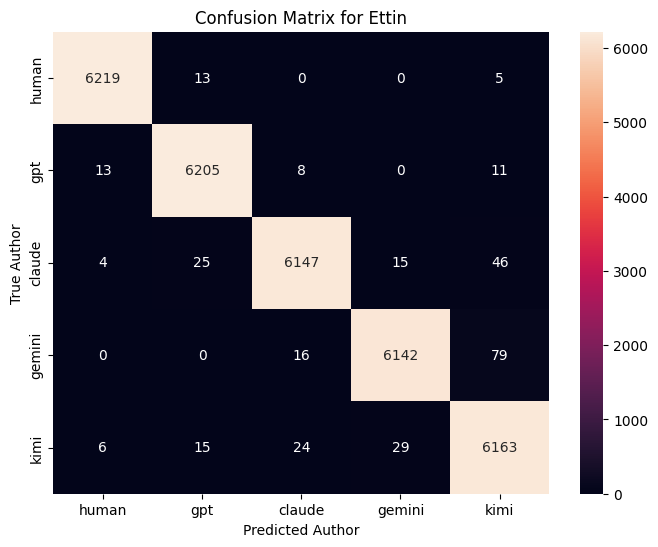


Classification Report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00      6237
         gpt       0.99      0.99      0.99      6237
      claude       0.99      0.99      0.99      6237
      gemini       0.99      0.98      0.99      6237
        kimi       0.98      0.99      0.98      6237

    accuracy                           0.99     31185
   macro avg       0.99      0.99      0.99     31185
weighted avg       0.99      0.99      0.99     31185



In [ ]:
predictions = finetune_trainer.predict(test_tokenized)
pred = np.argmax(predictions.predictions, axis = -1)
labels = test_df['labels'].values

cm = confusion_matrix(labels, pred)
plt.figure(figsize = (8,6))
sns.heatmap(cm,
            annot = True,
            fmt = 'd', # format the annotation from scientific to decimals
            xticklabels = [author for id, author in id_to_author.items()],
            yticklabels = [author for id, author in id_to_author.items()])
plt.xlabel('Predicted Author')
plt.ylabel('True Author')
plt.title('Confusion Matrix for Ettin')
plt.show()

print("\nClassification Report:")
print(classification_report(labels, pred, target_names = [author for id, author in id_to_author.items()]))

### Edit-resistance Analysis

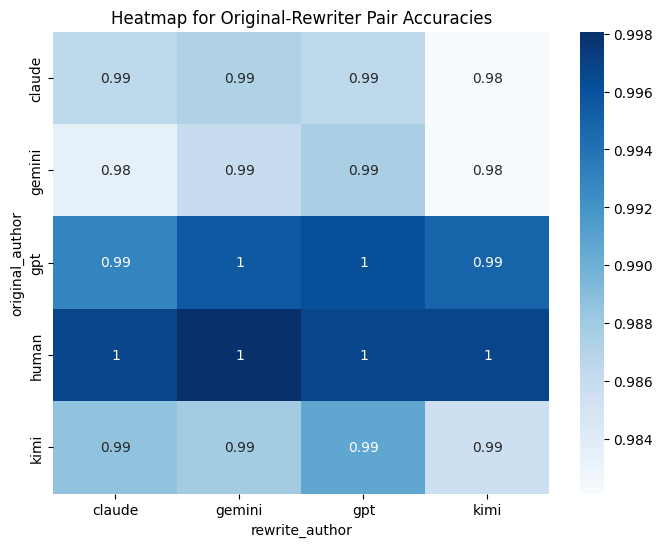

In [ ]:
test_df_copy = test_df.copy()
test_df_copy['pred'] = pred

# Compute accuracies for all original-rewrite pairs
grouped_test_df = test_df_copy.groupby(['original_author', 'rewrite_author']).apply(
    lambda row: (row['labels'] == row['pred']).mean(),
    include_groups = False).unstack()

plt.figure(figsize = (8, 6))
sns.heatmap(grouped_test_df,
            annot = True,
            cmap = 'Blues')
plt.title('Heatmap for Original-Rewriter Pair Accuracies')
plt.show()

### Save the final dataframe to parquet

In [ ]:
finetune_trainer.save_model("./finetuned_ettin")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]